# Imports

- Evaluate the effect of timing of P-fertilizer
- Samples with zero amount included. 
- Both regions

In [2]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import matplotlib as mpl
plt.style.use('ggplot')
import pickle

import geopandas as gpd

In [3]:
from CAgsalML.causal import  dml_sensitivity_analysis
from CAgsalML.tuning import GPOptimizer
from CAgsalML.transformers import SpatialTransform

INFO (2026-02-27 08:34:38,136) [__init__/<module> (line 54)]: Using balance version 0.12.0


In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import  r2_score
from sklearn.model_selection import train_test_split, cross_val_predict
from skopt.space import Categorical, Integer, Real

In [5]:
# Some options that define how the code is run

In [6]:
RANDOM_SEED = 43
np.random.seed(RANDOM_SEED)
import random
random.seed(RANDOM_SEED)

# Adjust data

In [7]:
DATA_VERSION = '260116'
data = pd.read_pickle(f'../data-definitive/data-dag-{DATA_VERSION}.pkl')
data = data.loc[data.crop_maize]  # Focus on maize only
data = data.loc[(data.outcome_prodkgha > 1000) & (data.outcome_prodkgha < 10000)]

adjustment_nodes = [
    # All adjustment set
    # 'accessibilityRAI', 'soil', 'elevation', 'otherManagement',
    # 'fieldHistory', 'weather',  'fertilizerTiming',
    # 'variety', 'investmentCap',
    # 'phenology', 'previousAdvice'
    
    # Minimal optimal
    'fieldHistory', 'weather', 'variety', 'previousAdvice',
    'otherManagement', 'fertilizerTiming', 'soil'
]
columns_dict = { # Includes all nodes, not only adjustment nodes
    'fieldHistory': [
        'fieldsize_value',  'history_maize', 'history_nocrop', 'history_legume',
        'history_rootandtuber', 'history_oilseed', 'history_maizelegume'
    ],
    'fertilizerAmount': ['fertN_total', 'fertP_total'],
    'accessibilityRAI': ['accessibility_rai'],
    'elevation': ['elevation_value'],
    'previousAdvice': ['treat_previousadvice'],
    'investmentCap': ['investing_capacity_index'],
    'weather': [
        '0to10perc_season_tmean', '0to10perc_season_srad',
        '0to10perc_season_prec', '0to10perc_season_rainydays',
        '10to20perc_season_tmean', '10to20perc_season_srad',
        '10to20perc_season_prec', '10to20perc_season_rainydays',
        '20to30perc_season_tmean', '20to30perc_season_srad',
        '20to30perc_season_prec', '20to30perc_season_rainydays',
        '30to40perc_season_tmean', '30to40perc_season_srad',
        '30to40perc_season_prec', '30to40perc_season_rainydays',
        '40to50perc_season_tmean', '40to50perc_season_srad',
        '40to50perc_season_prec', '40to50perc_season_rainydays',
        '50to60perc_season_tmean', '50to60perc_season_srad',
        '50to60perc_season_prec', '50to60perc_season_rainydays',
        '60to70perc_season_tmean', '60to70perc_season_srad',
        '60to70perc_season_prec', '60to70perc_season_rainydays',
        '70to80perc_season_tmean', '70to80perc_season_srad',
        '70to80perc_season_prec', '70to80perc_season_rainydays',
        '80to90perc_season_tmean', '80to90perc_season_srad',
        '80to90perc_season_prec', '80to90perc_season_rainydays',
        '90to100perc_season_tmean', '90to100perc_season_srad',
        '90to100perc_season_prec', '90to100perc_season_rainydays',
        '0to100perc_season_tmean', '0to100perc_season_srad',
        '0to100perc_season_prec', '0to100perc_season_rainydays',
    ],
    'soil': [
        'soilfert_cec', 'soilfert_oc', 'soilpp_clay',
        'soilpp_density', 'soilpp_sand', 'soil_sandy'
    ],
    'outcome': ['outcome_prodstd'],
    'fertilizerTiming': [
        'fertN_56leaves', 'fertN_810leaves', 'fertN_basal', 'fertN_emergence',
        'fertN_kneehigh','fertN_tasselingsilking', 'fertP_56leaves',
        'fertP_810leaves', 'fertP_basal', 'fertP_emergence', 'fertP_kneehigh',
        'fertP_tasselingsilking'
    ],
    'otherManagement': [
       'herbicide_post', 'herbicide_pre', 'herbicide_any', 'manure_any',
       'planting_handhoe', 'planting_ploughsowing', 'planting_string',
       'residue_burn', 'residue_feedtoanimals', 'residue_incorporateinthesoil',
       'residue_leaveonfield', 'residue_onfield'
    ],
    'variety': ['variety_hybrid', 'variety_recycled'],
    'phenology': ['phenology_losstd'],
    # 'crop': ['crop_maize'],
}

outcome_name = 'outcome_prodstd'
treatment_name = 'fertP_total'
# data['fertN_total'] /= 100 # Scale fertilizer amounts to 100 kg 
# data['fertP_total'] /= 100 
# Bad controls
bad_controls = [i for c in sorted(set(columns_dict) - set(adjustment_nodes)) for i in columns_dict[c]]
features = [i for v in columns_dict.values() for i in v]
features = list(sorted(list(set(features) - set(bad_controls) - {outcome_name, treatment_name})))
features.append('fertN_total')  # Include fertP_amount as a covariate

# Import geometries to add lat, lon as features
crs = 'EPSG:32736'
points = gpd.read_file('../data-definitive/geo/points.geojson')
points = points.set_index('fieldID')[['geometry']]
points = points.loc[data.index]
points = points.to_crs(crs)

admin = gpd.read_file('../data-definitive/geo/tza_shp/tza_admbnda_adm3_20181019.shp')
admin = admin.to_crs(crs)

# Perform a spatial join to assign ADM3_PCODE and ADM2_PCODE to each point
points = gpd.sjoin(points, admin[['ADM3_PCODE', 'ADM2_PCODE', 'geometry']], how="left", predicate="within")
points['ADM2_PCODE'] = points['ADM2_PCODE'].replace({'TZ2610': 'TZ2609'})
# Drop the 'index_right' column which is a byproduct of the sjoin
points = points.drop(columns=['index_right'])

# This is the data before transforming it for DAG, just in case
clean_data = pd.read_pickle(f'../data-definitive/maize-soya-clean-{DATA_VERSION}.pkl')

# Get subset of points in the zone of interest (west)
index_zone_subset = points.geometry.x.where(lambda x: x < 6e5).dropna().index
# index_zone_subset = data.index
points = points.loc[index_zone_subset]
data = data.loc[index_zone_subset]
clean_data = clean_data.loc[index_zone_subset]

# Add lan, lon as features
data['lat'] = (points.geometry.y - points.geometry.y.mean())/points.geometry.y.std()
data['lon'] = ((points.geometry.x - points.geometry.x.mean())/points.geometry.x.std())
features.extend(['lat', 'lon'])

In [8]:
data.loc[data.fertP_total == 0, data.filter(like='fertP').columns] = 0
data.loc[data.fertN_total == 0, data.filter(like='fertN').columns] = 0
data = data.loc[data.fertP_total > 0]  

In [9]:
TIMINGS = [
    'basal', 'emergence', 'kneehigh', '56leaves', '810leaves',
    'tasselingsilking'
]
# Check the variability of amounts.
data.loc[data.fertN_basal > 0, [f'fertP_{t}' for t in TIMINGS]].describe()

,fertP_basal,fertP_emergence,fertP_kneehigh,fertP_56leaves,fertP_810leaves,fertP_tasselingsilking
count,635.000000,631.000000,631.000000,631.000000,631.000000,631.000000
mean,0.966060,0.005283,0.002068,0.009192,0.014397,0.003215
std,0.124531,0.050293,0.030409,0.065501,0.080567,0.040574
min,0.333333,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,0.500000,0.517241,0.666667,0.600000,0.600000


In [10]:
T_series = data[treatment_name]
Y_series = data[outcome_name]

transformed_data = pd.DataFrame(index=data.index)
# Normalize features
numeric_features = list(data[features].select_dtypes(include='number').columns)
dummy_features = list((data.loc[:, data.isin([0, 1]).all()].columns))
timing_features = [f'fertP_{t}' for t in TIMINGS[:]]

numeric_features = list(sorted((set(numeric_features) - set(dummy_features)) - set(timing_features)))

transformed_data[numeric_features] = StandardScaler().fit_transform(
    data[numeric_features]
).astype(np.float32)
transformed_data[dummy_features] = data[dummy_features].astype(float)
transformed_data[timing_features] = data[timing_features]

# Drop those rows with no production
transformed_data = transformed_data.loc[data.outcome_prodkgha.dropna().index]

# Drop rows with values not within a feasible range
NORMALIZED_LIM = 5
transformed_data = transformed_data.loc[
    (transformed_data < NORMALIZED_LIM).all(axis=1) & 
    (transformed_data > -NORMALIZED_LIM).all(axis=1)
]
# Redefine index of samples
index_zone_subset = transformed_data.index
points = points.loc[index_zone_subset]
data = data.loc[index_zone_subset]
clean_data = clean_data.loc[index_zone_subset]

In [11]:
# Spatially demean the outcome
spatial_transformer_yield = SpatialTransform(
    points.geometry, maxlag=50e3, esitmator='cressie',
    model='matern', n_lags=50, use_nugget=True
)
spatial_transformer_yield.fit(data.loc[transformed_data.index].outcome_prodkgha)
transformed_data['outcome_prodstd'] = spatial_transformer_yield.transform_demean()
# Spatially demean the treatment
spatial_trans_index = points.index
spatial_transformer_fertilizer = SpatialTransform(
    points.geometry, maxlag=50e3, esitmator='cressie',
    model='matern', n_lags=50, use_nugget=True
)
spatial_transformer_fertilizer.fit(data[treatment_name])
transformed_data[treatment_name] = spatial_transformer_fertilizer.transform_demean()

In [12]:
# Add treatment and Keep only complete records
# transformed_data[treatment_name] = data[treatment_name]
transformed_data = transformed_data.dropna()
index_zone_subset = transformed_data.index
points = points.loc[index_zone_subset]
data = data.loc[index_zone_subset]
clean_data = clean_data.loc[index_zone_subset]

In [13]:
transformed_data.shape

(828, 90)

In [14]:
# Generate timing clusters
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

X_trans = np.sqrt(transformed_data[timing_features].values)

dbscan = DBSCAN(eps=np.sqrt(.03), min_samples=30) 
appl_clusters_df = pd.DataFrame(transformed_data[timing_features], columns=timing_features)
appl_clusters_df['cluster'] = dbscan.fit_predict(X_trans)
appl_clusters_df['Cluster name'] = appl_clusters_df['cluster'].map({
    -1: '0Noise',
    0: '100Basal',
    1: '100Emergence',
    2: '100V56',
})
# appl_clusters_df['Cluster name'] = appl_clusters_df['cluster']
(appl_clusters_df.groupby('Cluster name').agg(('mean' , 'std'))*100).astype(int)
# (appl_clusters_df.groupby('cluster').agg(('mean' , 'std'))*100).astype(int)

fertP_basal     fertP_emergence     fertP_kneehigh      \
                    mean std            mean std           mean std   
Cluster name                                                          
0Noise                27  28               6  16             13  31   
100Basal              99   0               0   0              0   0   
100Emergence           0   0             100   0              0   0   
100V56                 0   0               0   0              0   0   

             fertP_56leaves     fertP_810leaves     fertP_tasselingsilking  \
                       mean std            mean std                   mean   
Cluster name                                                                 
0Noise                   11  21              38  39                      2   
100Basal                  0   0               0   0                      0   
100Emergence              0   0               0   0                      0   
100V56                  100   0               0   0                      0   

                 cluster      
             std    mean std  
Cluster name                  
0Noise        10    -100   0  
100Basal       0       0   0  
100Emergence   0     100   0  
100V56         0     200   0

In [15]:
# How many samples where a single application timing was used
(appl_clusters_df.iloc[:, :6] > .99).any(axis=1).sum()

np.int64(773)

In [16]:
appl_clusters_df['Cluster name'].value_counts()

Cluster name
100Basal        570
100V56          120
0Noise           79
100Emergence     59
Name: count, dtype: int64

In [17]:
(appl_clusters_df.groupby(transformed_data['treat_previousadvice'])['Cluster name'].value_counts(normalize=True)*100).round(1)

treat_previousadvice  Cluster name
0.0                   100Basal        70.3
                      100V56          14.6
                      0Noise           9.2
                      100Emergence     5.9
1.0                   100Basal        48.1
                      100Emergence    24.1
                      0Noise          14.8
                      100V56          13.0
Name: proportion, dtype: float64

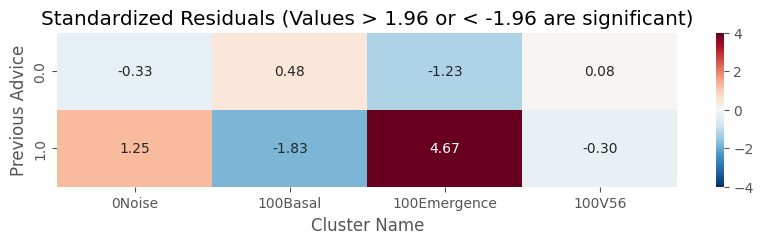

In [18]:
from scipy import stats
contingency_table = pd.crosstab(
    transformed_data.loc[appl_clusters_df.index]['treat_previousadvice'], appl_clusters_df['Cluster name']
)
contingency_table = contingency_table.iloc[:, :]
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

residuals = (contingency_table - expected) / np.sqrt(expected)

plt.figure(figsize=(10, 2))
sns.heatmap(residuals, annot=True, cmap="RdBu_r", center=0, fmt=".2f", vmin=-4, vmax=4)
plt.title("Standardized Residuals (Values > 1.96 or < -1.96 are significant)")
plt.xlabel("Cluster Name")
plt.ylabel("Previous Advice")
plt.show()

In [19]:
appl_clusters_df.join(data['soilpp_sand']).groupby('Cluster name')['soilpp_sand'].describe()

,count,mean,std,min,25%,50%,75%,max
Cluster name,,,,,,,,
0Noise,79.0,51.624473,4.711805,41.777778,48.388889,51.111111,53.000000,65.444444
100Basal,570.0,53.539766,6.098968,40.222222,49.333333,51.888889,57.333333,72.222222
100Emergence,59.0,55.949153,5.870075,45.111111,51.722222,55.555556,61.944444,67.222222
100V56,120.0,51.125000,4.409446,43.444444,47.527778,50.277778,53.916667,64.777778


In [20]:
appl_clusters_df.loc[appl_clusters_df['Cluster name']=='0Noise'].filter(like='fertN_').astype(bool).sum(axis=1).value_counts()

0.0    79
Name: count, dtype: int64

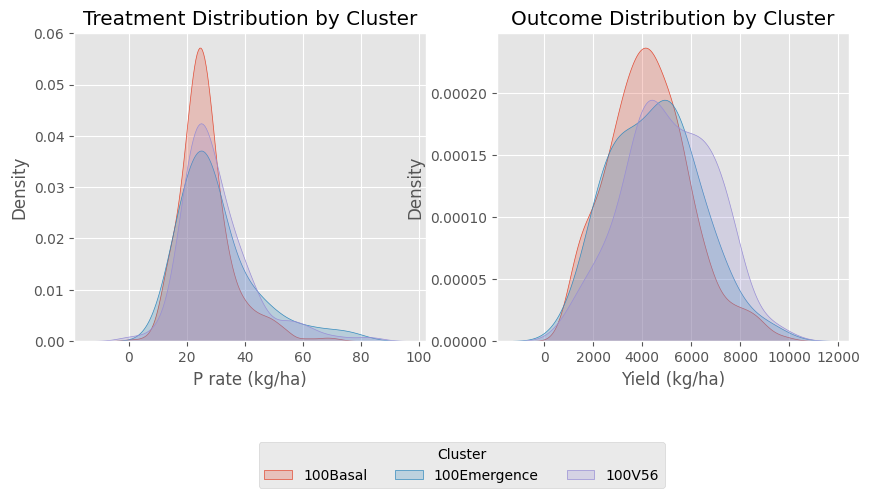

In [21]:
# Check the common support on treatment and outcome for the different clusters
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for c in np.unique(appl_clusters_df['Cluster name'].unique()):
    if c == '0Noise':
        continue
    ax = axes[0]
    sns.kdeplot(
        x=data.loc[
            appl_clusters_df.loc[appl_clusters_df['Cluster name'] == c].index,
            treatment_name
        ],
        fill=True, ax=ax,
        label=f'{c}'
    )
    ax.set_title('Treatment Distribution by Cluster')
    ax.set_xlabel('P rate (kg/ha)')

    ax = axes[1]
    sns.kdeplot(
        x=data.loc[
            appl_clusters_df.loc[appl_clusters_df['Cluster name'] == c].index,
            'outcome_prodkgha'
        ],
        fill=True, ax=ax,
        label=f'{c}'
    )
    ax.set_title('Outcome Distribution by Cluster')
    ax.set_xlabel('Yield (kg/ha)')

ax.legend(loc='lower center', bbox_to_anchor=(-0.1, -0.5, 0., .0), ncol=3, title='Cluster')
fig.savefig('../figures/P-fertilizer-support-clusters.pdf', bbox_inches='tight', dpi=300)

In [22]:
# Get weights to balance amount on each timing cluster.
from balance import Sample

appl_clusters_df[treatment_name] = data.loc[appl_clusters_df.index, treatment_name]
appl_clusters_df['outcome_prodkgha'] = data.loc[appl_clusters_df.index, 'outcome_prodkgha']

adj_dfs = []
for c in appl_clusters_df['Cluster name'].unique():
    sample = Sample.from_frame(
        appl_clusters_df.loc[appl_clusters_df['Cluster name'] ==  c, [treatment_name]].reset_index(),
        id_column='index'
    )
    target = Sample.from_frame(
        appl_clusters_df.loc[:, [treatment_name]].reset_index(),
        id_column='index'
    )
    sample_with_target = sample.set_target(target)
    adjusted = sample_with_target.adjust(method='cbps', cbps_method='exact', random_seed=RANDOM_SEED)
    adj_dfs.append(adjusted._df)
sample_weights = pd.concat(adj_dfs, axis=0).set_index('index').weight
sample_weights = sample_weights.clip(0.01, 10) # Trim extreme values and set to 10

WARNING (2026-02-27 08:34:43,086) [sample_class/from_frame (line 264)]: No weights passed. Adding a 'weight' column and setting all values to 1
WARNING (2026-02-27 08:34:43,111) [sample_class/from_frame (line 264)]: No weights passed. Adding a 'weight' column and setting all values to 1
INFO (2026-02-27 08:34:43,114) [cbps/cbps (line 411)]: Starting cbps function
INFO (2026-02-27 08:34:43,117) [adjustment/apply_transformations (line 305)]: Adding the variables: []
INFO (2026-02-27 08:34:43,117) [adjustment/apply_transformations (line 306)]: Transforming the variables: ['fertP_total']
INFO (2026-02-27 08:34:43,126) [adjustment/apply_transformations (line 343)]: Final variables in output: ['fertP_total']
INFO (2026-02-27 08:34:43,136) [cbps/cbps (line 461)]: The formula used to build the model matrix: ['fertP_total']
INFO (2026-02-27 08:34:43,137) [cbps/cbps (line 473)]: The number of columns in the model matrix: 10
INFO (2026-02-27 08:34:43,137) [cbps/cbps (line 474)]: The number of row

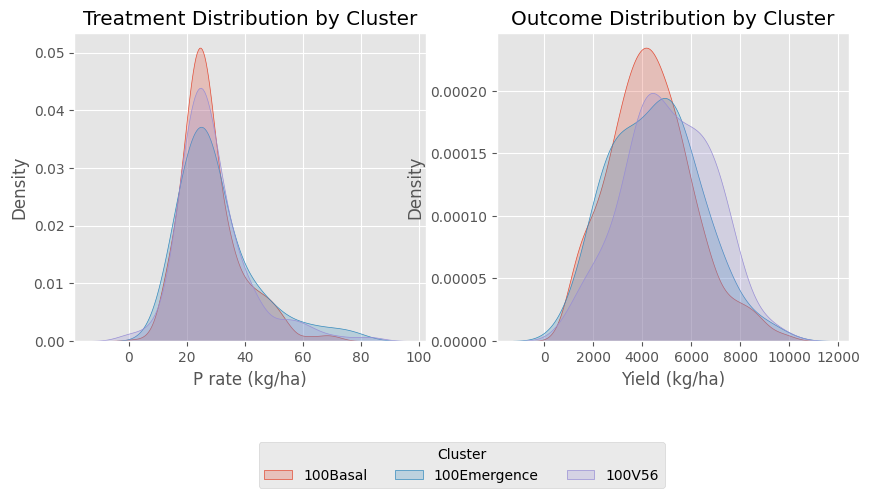

In [23]:
# Check the common support on treatment and outcome for the different clusters
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for c in np.unique(appl_clusters_df['Cluster name'].unique()):
    if c == '0Noise':
        continue
    ax = axes[0]
    sns.kdeplot(
        x=data.loc[
            appl_clusters_df.loc[appl_clusters_df['Cluster name'] == c].index,
            treatment_name
        ],
        fill=True, ax=ax,
        label=f'{c}',
        weights=sample_weights
    )
    ax.set_title('Treatment Distribution by Cluster')
    ax.set_xlabel('P rate (kg/ha)')

    ax = axes[1]
    sns.kdeplot(
        x=data.loc[
            appl_clusters_df.loc[appl_clusters_df['Cluster name'] == c].index,
            'outcome_prodkgha'
        ],
        fill=True, ax=ax,
        label=f'{c}',
        weights=sample_weights
    )
    ax.set_title('Outcome Distribution by Cluster')
    ax.set_xlabel('Yield (kg/ha)')

ax.legend(loc='lower center', bbox_to_anchor=(-0.1, -0.5, 0., .0), ncol=3, title='Cluster')
fig.savefig('../figures/P-fertilizer-support-clusters-balanced.pdf', bbox_inches='tight', dpi=300)

In [24]:
# data_backup = transformed_data.copy()
# transformed_data = data_backup.copy()

In [25]:
# Add the timing dummies to the data. Note that the noise dummy is not added
timing_dummies = pd.get_dummies(appl_clusters_df['Cluster name'], prefix='timing', drop_first=True).astype(int)
transformed_data = pd.concat([transformed_data, timing_dummies], axis=1)
features.extend(timing_dummies.columns)

# Effect estimation pipeline

## Generalized propensity score

In [26]:
x_names = list(timing_dummies.columns)
w_names = list(sorted(set(features) - set(x_names)))

training_idxs, testing_idxs = train_test_split(index_zone_subset, random_state=RANDOM_SEED)
print(f"{len(training_idxs)} training samples")
print(f"{len(testing_idxs)} testing samples")
print(f'N features: {len(x_names)+len(w_names)}')

621 training samples
207 testing samples
N features: 90


In [27]:
# First we need a model for the treatment
X_train = transformed_data.loc[training_idxs, w_names + x_names]
t_train = transformed_data.loc[training_idxs, treatment_name]

optimizer_treatment = GPOptimizer(
    model=RandomForestRegressor,
    model_kwargs=dict(
        max_depth=Integer(name='max_depth', low=2, high=10),
        max_features=Categorical(name='max_features', categories=['sqrt', 'log2']),
        min_samples_leaf=Integer(name='min_samples_leaf', low=1, high=50),
        n_estimators=100, random_state=RANDOM_SEED
    )
)

model_treatment, cv_scores_treatment = optimizer_treatment.cv_optimize(
    X_train, t_train,
    cv=5,
    cv_kwargs=dict(n_jobs=-1, scoring='r2'),
    gp_kwargs=dict(n_calls=50, n_initial_points=5, verbose=False, random_state=RANDOM_SEED)
)

In [28]:
model_treatment = model_treatment.fit(X_train, t_train)
test_score = r2_score(
    y_true=transformed_data.loc[testing_idxs, treatment_name],
    y_pred=model_treatment.predict(transformed_data.loc[testing_idxs, w_names + x_names])
)
print(f'CV R2 mean: {np.mean(cv_scores_treatment):.3f}')
print(f'Test R2: {test_score:.3f}')
print(f'Train R2: {r2_score(t_train, model_treatment.predict(X_train)):.3f}')

CV R2 mean: 0.194
Test R2: 0.167
Train R2: 0.552


In [29]:
pd.Series(
    model_treatment.feature_importances_,
    index=features
).sort_values(ascending=False).head(10)

fertP_56leaves                 0.178861
herbicide_any                  0.047090
fertP_basal                    0.046317
fertN_basal                    0.042886
90to100perc_season_srad        0.024768
fertP_emergence                0.022452
60to70perc_season_rainydays    0.021982
timing_100Basal                0.021140
fertN_810leaves                0.019706
80to90perc_season_tmean        0.018654
dtype: float64

<Axes: ylabel='Count'>

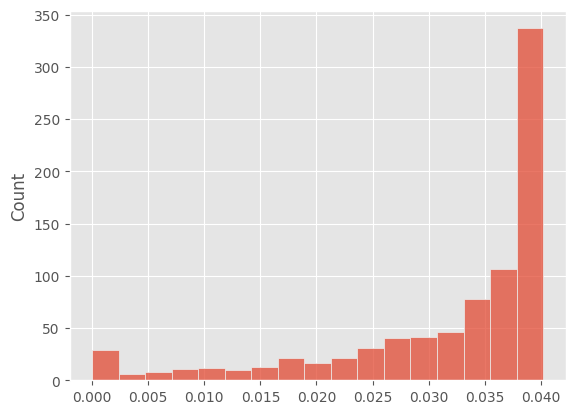

In [105]:
# Use Zhu et al. (2018) and Hirano and Gimbens (2004) approach to estimate PS for continuous treatments
T = transformed_data.loc[:, treatment_name].values
# Get the CV predictions to estimate the variance of residuals
T_pred = cross_val_predict(
    model_treatment, 
    X=transformed_data.loc[:, w_names + x_names],
    y=transformed_data.loc[:, treatment_name]
)
T_res = T - T_pred
res_var = np.var(T_res)

# Estimate the GPS
# gps = (1/(np.sqrt(2*np.pi*res_var)))*np.exp((-1/(2*res_var))*treatment_res**2)
gps_density = stats.norm.pdf(
    T, 
    loc=T_pred, 
    scale=res_var**.5 # Scale is sd in this function
)
sns.histplot(gps_density)

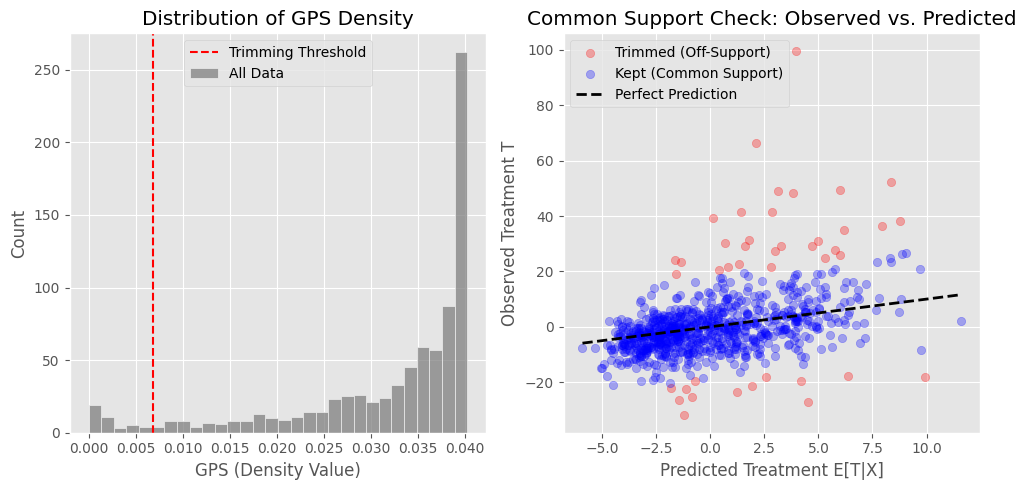

In [106]:
threshold = np.quantile(gps_density, 0.05)
mask_support = gps_density >= threshold
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
ax = axes[0]

sns.histplot(gps_density, bins=30, ax=axes[0], color='grey', label='All Data')
ax.axvline(threshold, color='red', linestyle='--', label='Trimming Threshold')
ax.set_title("Distribution of GPS Density")
ax.set_xlabel("GPS (Density Value)")
ax.legend()


ax = axes[1]
ax.scatter(T_pred[~mask_support], T[~mask_support], alpha=0.3, color='red', label='Trimmed (Off-Support)')
ax.scatter(T_pred[mask_support], T[mask_support], alpha=0.3, color='blue', label='Kept (Common Support)')
ax.plot([min(T_pred), max(T_pred)], [min(T_pred), max(T_pred)], 'k--', lw=2, label='Perfect Prediction')

ax.set_title("Common Support Check: Observed vs. Predicted")
ax.set_xlabel("Predicted Treatment E[T|X]")
ax.set_ylabel("Observed Treatment T")
ax.legend()

plt.tight_layout()
fig.savefig('../figures/P-fertilizer-gps-support.pdf', bbox_inches='tight', dpi=300)

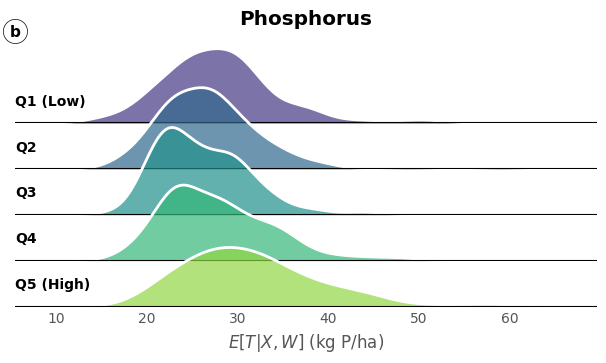

In [141]:
spatial_t = spatial_transformer_fertilizer.predict()
spatial_t = spatial_t[~np.isnan(spatial_t)] 
tmp_df = pd.DataFrame({'T_pred': (T_pred + spatial_t)[mask_support], 'Strata': pd.qcut(T[mask_support], 5, labels=False)})
tmp_df = tmp_df[tmp_df.T_pred < 60]  # For nicer viz
g = sns.FacetGrid(tmp_df, row="Strata", hue="Strata", aspect=9, height=.75, palette="viridis")
g.map(sns.kdeplot, "T_pred", clip_on=False, fill=True, alpha=0.7, lw=0)
g.map(sns.kdeplot, "T_pred", clip_on=False, color="w", lw=2)

g.fig.subplots_adjust(hspace=-.5)
g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)
g.axes.flat[0].set_title("Phosphorus", fontweight='bold', y=.99) 
g.axes.flat[-1].set_xlabel(r'$E[T|X,W]$'+' (kg P/ha)')

# Optional: Add text labels for each stratum
for ax, label in zip(g.axes.flat, ["Q1 (Low)", "Q2", "Q3", "Q4", "Q5 (High)"]):
    ax.text(0, 0.2, label, fontweight="bold", transform=ax.transAxes)
    ax.axhline(0, color='k', linestyle="-")
    ax.set_facecolor('none')
    ax.grid(None)
    ax.tick_params(length=0)

g.axes.flat[0].text(
    0, 1, 'b', transform=g.axes.flat[0].transAxes, va='center', ha='center', fontsize=11,
    fontweight='bold', bbox=dict(boxstyle='circle', fc='w', ec='k')
)
# g.set_xlim(10, 60)
g.fig.savefig('../figures/P-fertilizer-gps-support-strata.pdf', bbox_inches='tight', dpi=300)

In [33]:
# Trim extreme residuals
transformed_data_pstrimmed = transformed_data.copy()
transformed_data_pstrimmed = transformed_data_pstrimmed.loc[gps_density > threshold]

In [34]:
# transformed_data_pstrimmed = transformed_data.copy()
index_zone_subset = transformed_data_pstrimmed.index
points = points.loc[index_zone_subset]
data = data.loc[index_zone_subset]
clean_data = clean_data.loc[index_zone_subset]
transformed_data_pstrimmed.shape

(786, 93)

## Outcome model $q(X, W)$

In [35]:
training_idxs = training_idxs.intersection(index_zone_subset)
testing_idxs = testing_idxs.intersection(index_zone_subset)
X_train = transformed_data_pstrimmed.loc[training_idxs, w_names + x_names]
t_train = transformed_data_pstrimmed.loc[training_idxs, treatment_name]
T = transformed_data_pstrimmed.loc[:, treatment_name].values

In [36]:
y_train = transformed_data_pstrimmed.loc[training_idxs, outcome_name]

optimizer_q = GPOptimizer(
    model=RandomForestRegressor,
    model_kwargs=dict(
        max_depth=Integer(name='max_depth', low=2, high=10),
        max_features=Categorical(name='max_features', categories=['sqrt', 'log2']),
        min_samples_leaf=Integer(name='min_samples_leaf', low=1, high=50),
        n_estimators=100, random_state=RANDOM_SEED
    )
)

model_q, cv_scores_q = optimizer_q.cv_optimize(
    X_train, y_train,
    cv=5,
    cv_kwargs=dict(n_jobs=-1, scoring='r2'),
    gp_kwargs=dict(n_calls=100, n_initial_points=5, verbose=False, random_state=RANDOM_SEED)
)

In [37]:
model_q = model_q.fit(X_train, y_train)
test_score = r2_score(
    y_true=transformed_data_pstrimmed.loc[testing_idxs, outcome_name],
    y_pred=model_q.predict(transformed_data_pstrimmed.loc[testing_idxs, w_names + x_names])
)
print(f'CV R2 mean: {np.mean(cv_scores_q):.3f}')
print(f'Test R2: {test_score:.3f}')
print(f'Train R2: {r2_score(y_train, model_q.predict(X_train)):.3f}')

CV R2 mean: 0.041
Test R2: 0.013
Train R2: 0.227


In [38]:
pd.Series(
    model_q.feature_importances_,
    index=features
).sort_values(ascending=False).head(10)

fertP_56leaves              0.169549
herbicide_any               0.047345
0to10perc_season_srad       0.032133
20to30perc_season_srad      0.029826
90to100perc_season_tmean    0.028350
80to90perc_season_srad      0.027014
70to80perc_season_srad      0.023950
90to100perc_season_srad     0.022742
0to100perc_season_prec      0.021323
60to70perc_season_srad      0.020658
dtype: float64

## Effect estimation with DML 

In [39]:
from econml.dml import LinearDML
from sklearn.preprocessing import SplineTransformer, PolynomialFeatures
from sklearn.multioutput import MultiOutputRegressor

In [40]:
sandy_series = transformed_data_pstrimmed['soil_sandy'].to_numpy()
legume_series = transformed_data_pstrimmed['history_legume'].to_numpy()
sandy_series.mean()

In [41]:
# Homogeneous effect: Response curve is a line and it does not depend on timing
X_sand = np.vstack([~sandy_series.astype(bool), sandy_series]).T
W = transformed_data_pstrimmed.loc[:,features]
Y = transformed_data_pstrimmed.loc[:, outcome_name].to_numpy()
T = transformed_data_pstrimmed.loc[:, treatment_name].to_numpy()

lineardml_hom_estimate = LinearDML(
    model_y=model_q, 
    model_t=model_treatment, 
    discrete_treatment=False,
    cv=5,
    random_state=RANDOM_SEED, 
    fit_cate_intercept=False,
)
lineardml_hom_estimate = lineardml_hom_estimate.fit(
    Y=Y, T=T, W=W, X=X_sand,
    inference='statsmodels', cache_values=True,
)
lineardml_hom_estimate.summary(feature_names=['Non-sandy', 'Sandy'])

CATE Intercept Results:  No intercept was fitted!


,point_estimate,stderr,zstat,pvalue,ci_lower,ci_upper
Non-sandy,48.796,8.635,5.651,0.0,31.872,65.72
Sandy,48.531,14.554,3.335,0.001,20.006,77.055


In [42]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
cubic_spline_transformer = SplineTransformer(
    degree=3, n_knots=4, include_bias=True,
    knots='uniform',
)

# Transform the absolute T, and fit one Spatial Transformer for each component
# of the transformed T.
T_absolute = data.loc[transformed_data_pstrimmed.index, treatment_name].to_numpy()
T_trans = cubic_spline_transformer.fit_transform(T_absolute.reshape(-1, 1))
T_spline_spatial_avg = np.zeros_like(T_trans) # Spatial average vector for the Transformed treatment
for i in range(T_trans.ndim):
    t_col = T_trans[:, i]
    spatial_transformer = SpatialTransform(
        points.geometry, maxlag=50e3, esitmator='cressie',
        model='matern', n_lags=50, use_nugget=True
    )
    spatial_transformer.fit(t_col)
    t_trans_col = spatial_transformer.transform_demean() 
    T_spline_spatial_avg[:, i] = t_col - np.where(np.isnan(t_trans_col), 0, t_trans_col)

def spatial_anomaly_transform(t):
    return t - T_spline_spatial_avg

spatial_anomaly_transformer = FunctionTransformer(spatial_anomaly_transform)
treatment_featurizer = Pipeline([
    ('spline', cubic_spline_transformer),
    ('spatial anomaly', spatial_anomaly_transformer)
])

In [43]:
# Amount heterogeneous: response is a curve and it does not depend on timing
lineardml_amount_estimate = LinearDML(
    model_y=model_q, 
    model_t=MultiOutputRegressor(model_treatment), 
    treatment_featurizer=treatment_featurizer,
    discrete_treatment=False,
    cv=5,
    random_state=RANDOM_SEED,
    fit_cate_intercept=False, 
)
lineardml_amount_estimate = lineardml_amount_estimate.fit(
    Y=Y, T=T_absolute.reshape(-1, 1), W=W, X=X_sand,
    inference='statsmodels', cache_values=True,
)

In [44]:
spatial_y = pd.Series( # Vector of spatial average for Y.
    spatial_transformer_yield.predict(), index=spatial_trans_index
).loc[index_zone_subset].to_numpy()

param_cov_matrix = lineardml_amount_estimate._ortho_learner_model_final._model_final._model._param_var
param = lineardml_amount_estimate._ortho_learner_model_final._model_final._model._param

T0 = T_absolute.mean() # Reference or base fertilizer amount
def rate_inference(X, T0=T0, T1=100, y_offset=0, scale=1):
    """
    Function to make inference on the fitted estimator. We do this because the inference
    in the original object struggles with the spatial transformation when a subset of 
    the data is used
    """
    t_change = cubic_spline_transformer.transform([[T1]]) - cubic_spline_transformer.transform([[T0]])
    x_final_model = []
    for j in range(t_change.shape[1]):
        # For each element in t_change, multiply it with both columns of X_sand
        x_final_model.append(X * t_change[0, j])
    x_final_model = np.hstack(x_final_model)

    ate = (x_final_model.mean(axis=0).reshape(1, -1) @ param.reshape(-1, 1))[0, 0]
    ate_se = np.sqrt(
        x_final_model.mean(axis=0).reshape(1, -1) @ 
        param_cov_matrix @ 
        x_final_model.mean(axis=0).reshape(-1, 1)
    )[0, 0]

    # Calculate confidence interval
    ci_mean_lower = ate - 1.96 * ate_se
    ci_mean_upper = ate + 1.96 * ate_se

    # Calculate p-value
    if ate_se != 0:
        t_stat = ate / ate_se
        p_value = 2 * stats.norm.sf(np.abs(t_stat))
    else:
        p_value = np.nan # Or 1.0 if se is 0 and ate is also 0

    return {
        'mean_point': ate/scale, 
        'stderr_mean': ate_se/scale,
        'ci_mean_lower': ci_mean_lower/scale,
        'ci_mean_upper': ci_mean_upper/scale,
        'pvalue': p_value
    }

In [45]:
ate_df = pd.DataFrame(
    columns=['Mean', 'SE', 'LowerCI', 'UpperCI', 'pvalue'], 
    index=pd.MultiIndex(names=('Estimate', 'Soil'), levels=[[], []], codes=[[], []])
)
t25, t75 = np.quantile(T_absolute, [.25, .75])
ate_df.loc[('Amount rate', 'ATE'), ['Mean', 'SE', 'LowerCI', 'UpperCI', 'pvalue']] = \
    list(rate_inference(X_sand, T0=t25, T1=t75, y_offset=0, scale=(t75-t25)).values())
ate_df.loc[('Amount rate', 'Sandy'), ['Mean', 'SE', 'LowerCI', 'UpperCI', 'pvalue']] = \
    list(rate_inference(X_sand[X_sand[:, 1]==1], T0=t25, T1=t75, y_offset=0, scale=(t75-t25)).values())
ate_df.loc[('Amount rate', 'Non-sandy'), ['Mean', 'SE', 'LowerCI', 'UpperCI', 'pvalue']] = \
    list(rate_inference(X_sand[X_sand[:, 0]==1], T0=t25, T1=t75, y_offset=0, scale=(t75-t25)).values())
ate_df

Mean         SE    LowerCI     UpperCI    pvalue
Estimate    Soil                                                            
Amount rate ATE        43.683341  11.486418  21.169962   66.196721  0.000143
            Sandy      70.793115  21.786175  28.092212  113.494019  0.001156
            Non-sandy  32.810437  13.514611     6.3218   59.299075  0.015192

In [46]:
# Timing hetrogeneous: response is a line, but it is different for each of the timing clusters
W = transformed_data_pstrimmed.loc[:, list(set(features) - set(x_names))].to_numpy()
X = transformed_data_pstrimmed.loc[:, x_names].to_numpy()
X = np.hstack([(1 - X.any(axis=1)).reshape(-1, 1), X]) # Add a feature for the other cluster category
X = np.hstack([X * ~sandy_series.astype(bool).reshape((-1, 1)), X * sandy_series.reshape((-1, 1))])

x_names_cate = ['other'] + x_names
x_names_cate = [f'{j}_{i}' for j in ('nosandy', 'sandy') for i in x_names_cate]

lineardml_time_estimate = LinearDML(
    model_y=model_q, 
    model_t=model_treatment, 
    discrete_treatment=False,
    cv=5,
    random_state=RANDOM_SEED,
    fit_cate_intercept=False,
)
lineardml_time_estimate = lineardml_time_estimate.fit(
    Y=Y, T=T, W=W, X=X,
    inference='statsmodels', cache_values=True,
    sample_weight=sample_weights[transformed_data_pstrimmed.index]
)
print('Timing heterogeneous effect on Non-sandy:')
lineardml_time_estimate.ate_inference(X[X_sand[:, 0]==1])

Timing heterogeneous effect on Non-sandy:


In [47]:
print('Timing heterogeneous effect on Sandy:')
lineardml_time_estimate.ate_inference(X[X_sand[:, 1]==1])

Timing heterogeneous effect on Sandy:


In [48]:
from sklearn.preprocessing import FunctionTransformer

T_absolute = data.loc[transformed_data_pstrimmed.index, treatment_name].to_numpy()
T_bins = np.arange(10, 60, 10)
def transform_to_bins(t):
    dummies = pd.get_dummies(pd.cut(t.flatten(), T_bins)).astype(int).to_numpy()
    return dummies
bin_transformer = FunctionTransformer(transform_to_bins) 

In [49]:
# Amount heterogeneous but using bins response is a curve and it does not depend on timing
X_bins = bin_transformer.fit_transform(T_absolute)
X_bins_sand = np.hstack([
    X_bins*X_sand[:, 0].reshape(-1,1),
    X_bins*X_sand[:, 1].reshape(-1,1),
])

lineardml_amountcat_estimate = LinearDML(
    model_y=model_q, 
    model_t=model_treatment, 
    discrete_treatment=False,
    cv=5,
    random_state=RANDOM_SEED,
    fit_cate_intercept=False, 
)
lineardml_amountcat_estimate = lineardml_amountcat_estimate.fit(
    Y=Y, T=T, W=W, X=X_bins_sand,
    inference='statsmodels', cache_values=True,
)
print('Amount heterogeneous bins effect on Non-sandy:')
x_bin_sand_names = [f'{s}sand:{i}-{i+10}' for s in ('no', '') for i in T_bins[:-1]]
lineardml_amountcat_estimate.summary(feature_names=x_bin_sand_names)

Amount heterogeneous bins effect on Non-sandy:
CATE Intercept Results:  No intercept was fitted!


,point_estimate,stderr,zstat,pvalue,ci_lower,ci_upper
nosand:10-20,79.032,20.774,3.804,0.0,38.316,119.749
nosand:20-30,26.553,17.916,1.482,0.138,-8.562,61.669
nosand:30-40,73.274,23.496,3.119,0.002,27.223,119.325
nosand:40-50,54.589,31.317,1.743,0.081,-6.79,115.968
sand:10-20,52.307,29.955,1.746,0.081,-6.404,111.018
sand:20-30,35.298,26.406,1.337,0.181,-16.458,87.053
sand:30-40,14.834,41.545,0.357,0.721,-66.592,96.26
sand:40-50,92.301,45.022,2.05,0.04,4.06,180.542


In [50]:
lineardml_time_estimate.score_, lineardml_amount_estimate.score_, lineardml_hom_estimate.score_, lineardml_amountcat_estimate.score_

## Visualize effects

In [51]:
maize_std = clean_data.loc[index_zone_subset].maizeprodkg_ha.std()
maize_mean = clean_data.loc[index_zone_subset].maizeprodkg_ha.mean()
cluster_count_soil = appl_clusters_df.join(transformed_data_pstrimmed.soil_sandy).groupby(['soil_sandy', 'Cluster name']).cluster.count()

In [52]:
# ATE for the different model setups
estimates_dict = {
    'No Het.': lineardml_hom_estimate, 'Amount rate': lineardml_amount_estimate,
    'Amount Cat.': lineardml_amountcat_estimate, 'Appl. Strat.': lineardml_time_estimate, 
}
# ate_df = pd.DataFrame(
#     columns=['Mean', 'SE', 'LowerCI', 'UpperCI', 'pvalue'], 
#     index=pd.MultiIndex(names=('Estimate', 'Soil'), levels=[[], []], codes=[[], []])
# )
for est_name, est in estimates_dict.items():
    for n, soil in enumerate(('Non-sandy', 'Sandy')):
        # ate_df.loc[(est_name, soil)] = soil
        if est_name in ('No Het.', 'Amount rate'):
            if est_name == 'Amount rate':
                continue
            X_ = X_sand
        elif est_name == 'Amount Cat.':
            X_ = X_bins_sand
        else:
            X_ = X
        ate_df.loc[(est_name, 'ATE'), 'Mean'] = est.ate(X_)
        ate_df.loc[(est_name, 'ATE'), 'SE'] = est.ate_inference(X_).mean_pred_stderr 
        ate_df.loc[(est_name, 'ATE'), 'pvalue'] = est.ate_inference(X_).pvalue()
        ate_df.loc[(est_name, 'ATE'), ['LowerCI', 'UpperCI']] = est.ate_interval(X_)
        X_ = X_[X_sand[:, n]==1]
        ate_df.loc[(est_name, soil), 'Mean'] = est.ate(X_)
        ate_df.loc[(est_name, soil), 'SE'] = est.ate_inference(X_).mean_pred_stderr 
        ate_df.loc[(est_name, soil), 'pvalue'] = est.ate_inference(X_).pvalue()
        ate_df.loc[(est_name, soil), ['LowerCI', 'UpperCI']] = est.ate_interval(X_)

ate_df = ate_df.sort_index()

In [53]:
ate_df.loc[(slice(None), ['Non-sandy', 'Sandy']), :].style.format({
    'Mean': '{:.1f}', 'SE': '{:.3f}', 'pvalue': '{:.3f}'
})

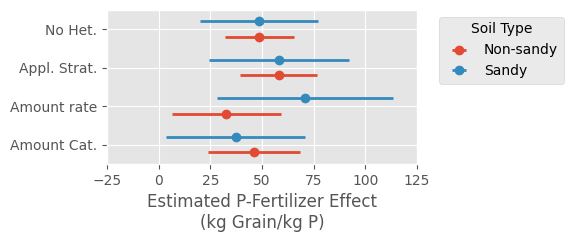

In [54]:
fig, ax = plt.subplots(1, 1, figsize=(4, 2))

for soil in ('Non-sandy', 'Sandy'):
    tmp_soil_df = ate_df.loc[(slice(None), soil), :].reset_index(level=1)
    y = np.arange(len(tmp_soil_df)) - (0.2 if soil == 'Non-sandy' else -0.2)
    ax.errorbar(
        y=y,
        x=tmp_soil_df['Mean'],
        xerr=np.abs(tmp_soil_df[['LowerCI', 'UpperCI']].values.T - tmp_soil_df['Mean'].values),
        fmt='o', linewidth=2, label=soil
    )
ax.set_yticks(np.arange(len(tmp_soil_df)))
ax.set_yticklabels(tmp_soil_df.index)
ax.set_xlabel('Estimated P-Fertilizer Effect\n(kg Grain/kg P)')
ax.set_ylim(-0.5, 3.5)
# ax.set_title('Sample N-AE from\nthe different estimators')
ax.set_xlim(-25, 125)
# ax.axvline(cf_estimator.ate(X) * maize_std/100, color='k', linestyle='--', label='ATE')
ax.legend(title='Soil Type', bbox_to_anchor=(1.05, 1), loc='upper left')

In [55]:
timing_pretty_names = {
    'other': 'Other', 
    'timing_100V56': '100% V5-6', 
    'timing_100Basal': '100% Basal', 
    'timing_100Emergence': '100% Emergence'
}

In [56]:
cluster_count_soil

soil_sandy  Cluster name
0.0         0Noise           47
            100Basal        389
            100Emergence     32
            100V56           93
1.0         0Noise           12
            100Basal        168
            100Emergence     25
            100V56           20
Name: cluster, dtype: int64

In [57]:
cluster_count_soil.index = cluster_count_soil.index.map({
    (0.0, '0Noise'): ('Non-sandy', 'Other'),
    (0.0, '100V56'): ('Non-sandy', '100% V5-6'),
    (0.0, '100Basal'): ('Non-sandy', '100% Basal'),
    (0.0, '100Emergence'): ('Non-sandy', '100% Emergence'),
    (1.0, '0Noise'): ('Sandy', 'Other'),
    (1.0, '100V56'): ('Sandy', '100% V5-6'),
    (1.0, '100Basal'): ('Sandy', '100% Basal'),
    (1.0, '100Emergence'): ('Sandy', '100% Emergence'),
 })

CATE Intercept Results:  No intercept was fitted!


point_estimate  stderr  zstat  pvalue  ci_lower  \
Non-sandy Other                   -3.630  16.737 -0.217   0.828   -36.434   
          100% Basal              73.416  12.330  5.954   0.000    49.250   
          100% Emergence          48.375  38.953  1.242   0.214   -27.971   
          100% V5-6               28.144  17.895  1.573   0.116    -6.930   
Sandy     Other                  -34.111  37.177 -0.918   0.359  -106.976   
          100% Basal              67.138  22.154  3.030   0.002    23.717   
          100% Emergence          65.685  32.682  2.010   0.044     1.630   
          100% V5-6               27.588  32.897  0.839   0.402   -36.888   

                          ci_upper  
Non-sandy Other             29.174  
          100% Basal        97.582  
          100% Emergence   124.721  
          100% V5-6         63.218  
Sandy     Other             38.754  
          100% Basal       110.560  
          100% Emergence   129.740  
          100% V5-6         92.065

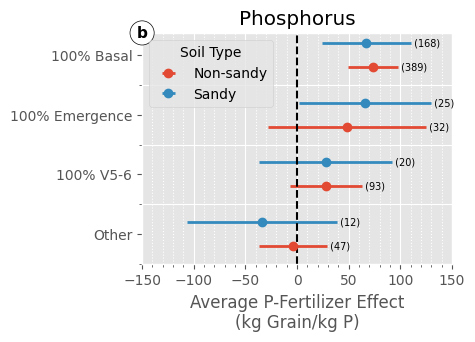

In [58]:
def rename_soil_cluster(i):
    soil = i.split('_')[0]
    soil = 'Sandy' if soil == 'sandy' else 'Non-sandy'
    appl = '_'.join(i.split('_')[1:])
    return (soil, timing_pretty_names[appl])
timing_coefs = pd.read_html(
    lineardml_time_estimate.summary(feature_names=x_names_cate).tables[0].as_html()
    , header=0, index_col=0
)[0]
timing_coefs.index = timing_coefs.index.map(rename_soil_cluster)

cluster_order = [
    'Other', # Noise
    '100% V5-6', '100% Emergence', '100% Basal' 
]

tmp_df = timing_coefs # Convert to N-AE

fig, ax = plt.subplots(1, 1, figsize=(4, 3))
y = np.arange(tmp_df.loc['Sandy'].shape[0])
for soil in ('Non-sandy', 'Sandy'):
    tmp_tmp_df = tmp_df.loc[soil].loc[cluster_order]
    y_offset = y + (0.2 if soil == 'Sandy' else -0.2)
    ax.errorbar(
        y=y_offset,
        x=tmp_tmp_df['point_estimate'],
        xerr=np.abs(tmp_tmp_df[['ci_lower', 'ci_upper']].values.T - tmp_tmp_df['point_estimate'].values),
        fmt='o', linewidth=2, label=soil
    )
    for n, cluster in enumerate(cluster_order[::]):
        ax.text(
            tmp_tmp_df.loc[cluster, 'ci_upper'], y_offset[n], 
            f' ({cluster_count_soil.loc[(soil, cluster)]}) ',
            ha='left', va='center', fontsize=7
        )
ax.text(
    0, 1, 'b', transform=ax.transAxes, va='center', ha='center', fontsize=11,
    fontweight='bold', bbox=dict(boxstyle='circle', fc='w', ec='k')
)
ax.set_title('Phosphorus')
ax.set_xlabel('Average P-Fertilizer Effect\n(kg Grain/kg P)')
# ax.set_ylim(-0.5, len(x_names)+0.5)
ax.set_xlim(-150, 150)
# ax.set_title('Songwe region')
ax.axvline(0, color='k', linestyle='--')
ax.set_yticks(y)
ax.set_yticks(y-.5, minor=True)
ax.grid(which='minor', axis='y', linestyle='-')
ax.grid(which='major', axis='y')
ax.set_xticks(np.arange(-150, 150, 10), minor=True)
ax.grid(which='minor', axis='x', linestyle=':')
ax.set_yticklabels(cluster_order)
ax.legend(loc='upper left', title='Soil Type')

fig.savefig('../figures/P-fertilizer-timing-effects.pdf', bbox_inches='tight', dpi=300)
tmp_df

In [59]:
T_absolute = data.loc[transformed_data_pstrimmed.index, treatment_name].to_numpy()
Y_absolute = data.loc[transformed_data_pstrimmed.index, 'outcome_prodkgha'].to_numpy()

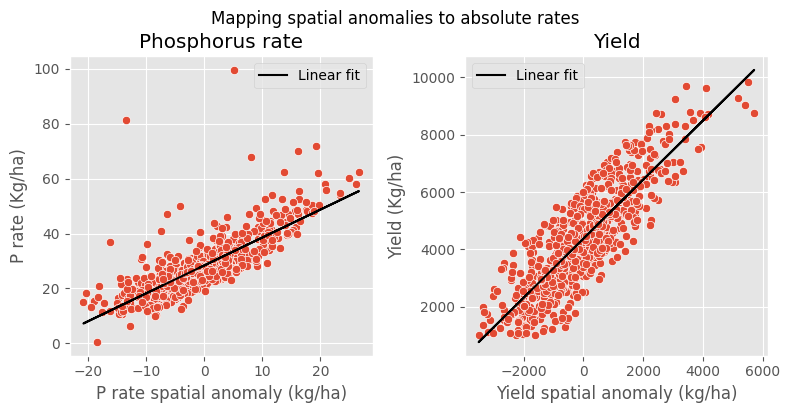

In [60]:
from statsmodels.api import OLS, add_constant

# A model to map spaital anomalies to absolute rates
fertilizer_anomaly_to_absolute = OLS(
    endog=T_absolute,
    exog=add_constant(T)
).fit()

yield_anomaly_to_absolute = OLS(
    endog=Y_absolute,
    exog=add_constant(Y)
).fit()

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

ax = axes[0]
sns.scatterplot(x=T, y=T_absolute, ax=ax)
ax.set_xlabel('P rate spatial anomaly (kg/ha)')
ax.set_ylabel('P rate (Kg/ha)')
ax.plot(
    T, fertilizer_anomaly_to_absolute.predict(add_constant(T)), 
    color='k', linestyle='-', label='Linear fit'
)
plt.tight_layout()
ax.set_title('Phosphorus rate')
ax.legend()

ax = axes[1]
sns.scatterplot(x=Y, y=Y_absolute, ax=ax)
ax.set_xlabel('Yield spatial anomaly (kg/ha)')
ax.set_ylabel('Yield (Kg/ha)')
ax.plot(
    Y, yield_anomaly_to_absolute.predict(add_constant(Y)), 
    color='k', linestyle='-', label='Linear fit'
)
plt.tight_layout()
ax.set_title('Yield')
ax.legend()

fig.suptitle('Mapping spatial anomalies to absolute rates', y=1.02)

fertilizer_anomaly_to_absolute.rsquared, yield_anomaly_to_absolute.rsquared

Around 60% of the yield and nitrogen rates is not explained by spatial patterns. 

In [61]:
spatial_t = pd.Series(
    spatial_transformer_fertilizer.predict(), index=spatial_trans_index
).loc[index_zone_subset].to_numpy()
spatial_y = pd.Series(
    spatial_transformer_yield.predict(), index=spatial_trans_index
).loc[index_zone_subset].to_numpy()
# sns.regplot(
#     x=spatial_t, y=spatial_y 
# )

In [62]:
spatial_y_avg = np.nanmean(spatial_y)
spatial_t_avg = np.nanmean(spatial_t)
print(f'Average spatial N Rate: {spatial_y_avg:.0f} Kg N/ha')
print(f'Average spatial N Rate: {spatial_t_avg.mean():.0f} Kg N/ha')
spatial_n_avg = 30

Average spatial N Rate: 4377 Kg N/ha
Average spatial N Rate: 28 Kg N/ha


In [63]:
t_grid = np.linspace(np.percentile(T, 2.5), np.percentile(T, 97.5), 100)
t_absolute_grid = fertilizer_anomaly_to_absolute.predict(add_constant(t_grid))

def plot_response_curve(est, ax, X=None, ci=True, kwargs_line={}, kwargs_ci={},
                        anomaly=True, t_grid=None):
    lift_inference = []
    if t_grid is None: 
        t_grid = np.linspace(np.percentile(T, 2.5), np.percentile(T, 97.5), 100)
    if isinstance(est, LinearDML):
        for t in t_grid: 
            if ci:
                ate_inf = est.ate_inference(X=X, T0=T0, T1=t)
                lift_inference.append((ate_inf.mean_point, *ate_inf.conf_int_mean()))
            else:
                lift_inference.append([est.ate(X=X, T0=0, T1=t)])
    elif est.shape[0] == 3:
        lift_inference = est.T
    else:
        lift_inference = est.reshape(-1, 1)
            
    lift_inference = np.array(lift_inference)
    if anomaly:
        t_grid_ = t_grid 
        lift_inference_ = lift_inference
    else:
        lift_inference_ = lift_inference + spatial_y_avg
        t_grid_ = t_grid + spatial_n_avg
    
    sns.lineplot(
        x=t_grid_, y=lift_inference_[:, 0], ax=ax,
        **kwargs_line
    )
    if ci:
        if not kwargs_ci:
            kwargs_ci=dict(alpha=.1)
        ax.fill_between(
            x=t_grid_, y1=lift_inference_[:,1], 
            y2=lift_inference_[:,2], **kwargs_ci
        )
    if anomaly:
        ax.set_xlabel('P-Fertilizer rate (kg/ha)')
        ax.set_ylabel('Increase in yield relative to\nusing the average P rate (kg/ha)')
    else:
        ax.set_xlabel('P-Fertilizer rate (kg/ha)')
        ax.set_ylabel('Yield (kg/ha)')

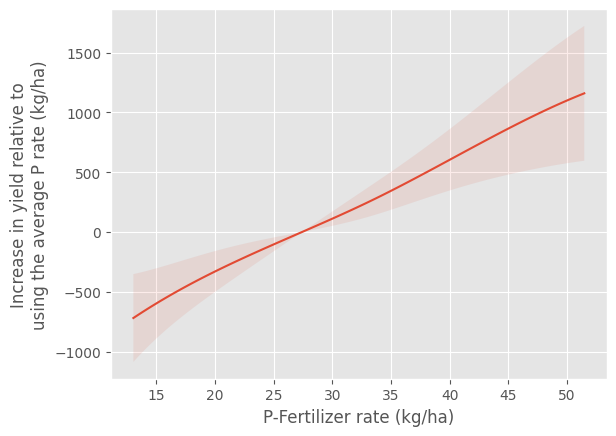

In [64]:
t_grid = np.linspace(np.percentile(T_absolute, 2.5), np.percentile(T_absolute, 97.5), 100)
lift_inference_rate = {
    'All': np.zeros(shape=(3, len(t_grid))),
    'Non-sandy': np.zeros(shape=(3, len(t_grid))),
    'Sandy': np.zeros(shape=(3, len(t_grid)))
}
for n, t in enumerate(t_grid): 
    ate_inf = rate_inference(X_sand, T0=T0, T1=t, y_offset=spatial_y)
    lift_inference_rate['All'][:, n] = (ate_inf['mean_point'], ate_inf['ci_mean_lower'], ate_inf['ci_mean_upper'])
    ate_inf = rate_inference(X_sand[X_sand[:, 1]==0], T0=T0, T1=t, y_offset=spatial_y)
    lift_inference_rate['Non-sandy'][:, n] = (ate_inf['mean_point'], ate_inf['ci_mean_lower'], ate_inf['ci_mean_upper'])
    ate_inf = rate_inference(X_sand[X_sand[:, 1]==1], T0=T0, T1=t, y_offset=spatial_y)
    lift_inference_rate['Sandy'][:, n] = (ate_inf['mean_point'], ate_inf['ci_mean_lower'], ate_inf['ci_mean_upper'])
    

fig, ax = plt.subplots(1, 1)
plot_response_curve(lift_inference_rate['All'], ax, t_grid=t_grid)

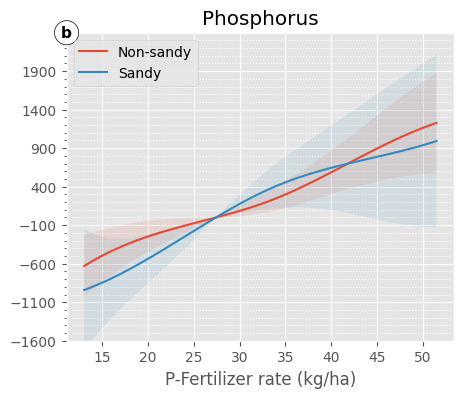

In [65]:
fig, ax =plt.subplots(1, 1, figsize=(5, 4))
plot_response_curve(
    lift_inference_rate['Non-sandy'], ax, X=X_sand[X_sand[:,0].astype(bool)],
    kwargs_line=dict(label='Non-sandy'), t_grid=t_grid
)
plot_response_curve(
    lift_inference_rate['Sandy'], ax, X=X_sand[X_sand[:,1].astype(bool)],
    kwargs_line=dict(label='Sandy'), t_grid=t_grid
)
ax.set_title('Average P-fertilizer response')
ax.legend(loc='upper left')
ax.text(
    0, 1, 'b', transform=ax.transAxes, va='center', ha='center', fontsize=11,
    fontweight='bold', bbox=dict(boxstyle='circle', fc='w', ec='k')
)
ax.set_title('Phosphorus')
ax.set_yticks(np.arange(-1600, 2500, 500))
ax.set_yticks(np.arange(-1600, 2500, 100), minor=True)
ax.set_ylim(-1600, 2399)
ax.set_ylabel('')
ax.grid(which='minor', linestyle=':')
# ax.set_xlim(0, 100*T.max())
fig.savefig('../figures/P-fertilizer-dose-response-curve.pdf', bbox_inches='tight', dpi=300)

In [66]:
pd.DataFrame([Y_absolute, T_absolute, X_sand[:, 1]]).T.groupby(2).mean()

,0,1
2,,
0.0,4418.421768,26.961498
1.0,4165.428355,28.575209


Text(0.5, 1.0, 'Distribution of P fertilizer application rates\n(spatial anomaly)')

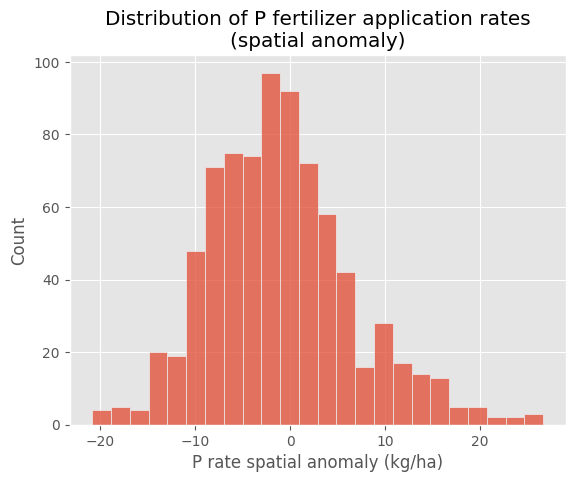

In [67]:
ax = sns.histplot(T)
ax.set_xlabel('P rate spatial anomaly (kg/ha)')
ax.set_title('Distribution of P fertilizer application rates\n(spatial anomaly)')

In [68]:
spatial_t_mean_sand = pd.DataFrame([
    spatial_t, X_sand[:, 1] 
]).T.groupby(1).mean().iloc[:, 0]
spatial_t_mean_sand.index = ['Non-sandy', 'Sandy']
spatial_t_mean_sand.name = 'N spatial mean'
spatial_t_mean_sand

Non-sandy    28.104471
Sandy        29.135120
Name: N spatial mean, dtype: float64

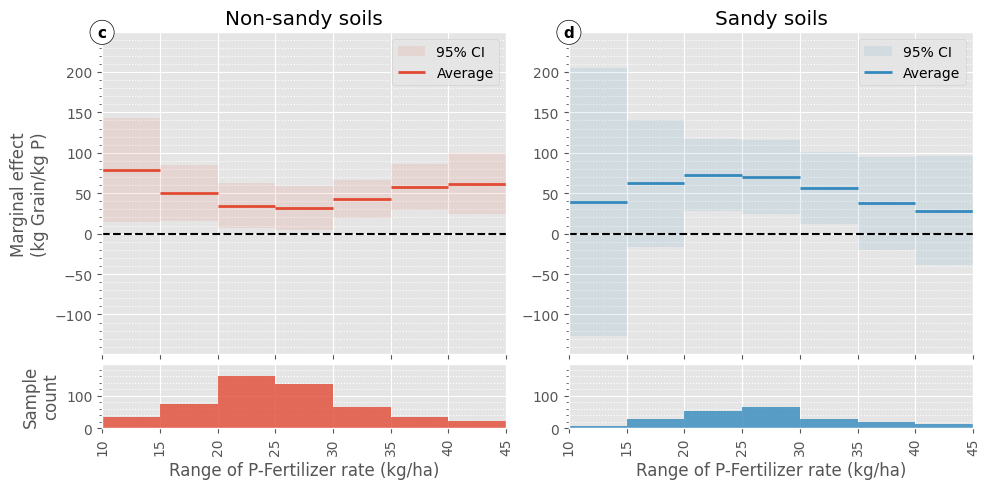

In [69]:
# Marginal response for amount ranges
step_size = 5
fig, axes = plt.subplots(2, 2, figsize=(10, 5), sharey=False, sharex=True, height_ratios=[5, 1])

x_ = np.arange(10, 50, step_size)
x = np.arange(10, 50, step_size)
x_ = x 
lift_amount_df = pd.DataFrame(
    columns=pd.MultiIndex.from_tuples([
        ('Non-sandy', 'Mean'), ('Non-sandy', 'LowerCI'), ('Non-sandy', 'UpperCI'),
        ('Sandy', 'Mean'), ('Sandy', 'LowerCI'), ('Sandy', 'UpperCI')
    ]), index=x_[:-1]
)
for n, soil in enumerate(('Non-sandy', 'Sandy')):
    ax = axes[0][n]
    ax2 = axes[1][n]
    ax.axhline(0, color='k', linestyle='--')
    lift_inference = []
    for i, t in enumerate(x[:-1]):
        t1 = x[i+1]
        ate_inf = rate_inference(X=X_sand[X_sand[:, n].astype(bool)],  T0=t, T1=t1)
        lift_inference.append(
            np.array([ate_inf['mean_point'], ate_inf['ci_mean_lower'], ate_inf['ci_mean_upper']])/(t1 - t)
        )
        lift_amount_df.loc[t, (soil, slice(None))] = lift_inference[-1]
        T_ = T_absolute[X_sand[:, n].astype(bool)]
        # ax.text(
        #     x_[i] + (x_[i+1] - x_[i])/2, lift_inference[-1][2]+1, f'({((T_ >= t) & (T_ < t1)).sum()})', 
        #     ha='center', fontsize=7
        # )
        ax.fill_between(
            x=[x_[i], x_[i+1]], y1=lift_inference[-1][1], y2=lift_inference[-1][2],
            alpha=0.1, color=('#E24A33', '#348ABD')[n], linewidth=0, label='95% CI' if i==0 else None
        )

        ax2.fill_between(
            x=[x_[i], x_[i+1]], y1=0, y2=((T_ >= t) & (T_ < t1)).sum(),
            alpha=.8, color=("#E24A33", '#348ABD')[n], linewidth=0, label='95% CI' if i==0 else None
        )
    lift_inference = np.array(lift_inference)
    err = np.abs(lift_inference[:, 1:] - lift_inference[:, 0].reshape(-1, 1)).T 
    ax.hlines(
        y=lift_inference[:, 0], xmin=x_[:-1], xmax=x_[1:], linewidth=2,
        label='Average', color=('#E24A33', '#348ABD')[n]
    )
    if n == 0: ax.set_ylabel('Marginal effect\n(kg Grain/kg P)')
    ax.set_xticks(x_[:])
    ax.set_yticks(np.arange(-150, 250, 10), minor=True)
    ax.grid(which='minor', linestyle=':')
    ax.set_ylim(-149, 249)
    ax.set_xlim(x_[0], x_[-1])
    ax.set_title(f'{soil} soils')
    ax.text(
        0, 1, ('c', 'd')[n], transform=ax.transAxes, va='center', ha='center', fontsize=11,
        fontweight='bold', bbox=dict(boxstyle='circle', fc='w', ec='k')
    )
    ax.legend(loc='upper right')
    # Histplot
    ax2.set_ylim(0, 199)
    ax2.set_yticks(np.arange(0, 200, 20), minor=True)
    ax2.grid(which='minor', linestyle=':')
    ax2.set_xticklabels([f'{x_[i]:.0f}' for i, _ in enumerate(x_[:])], rotation=90)
    ax2.set_xlabel('Range of P-Fertilizer rate (kg/ha)')
    # ax2.yaxis.tick_right()
    # ax2.yaxis.set_label_position("right")
    if n == 0: ax2.set_ylabel('Sample\ncount', )
plt.tight_layout()
plt.subplots_adjust(hspace=.05)


# fig.suptitle(f'Average marginal effect of N Fertilizer for\ngiven  {step_size} kg/ha N fertilizer ranges', y=1.05)
fig.savefig('../figures/P-fertilizer-marginal-dose-response.pdf', bbox_inches='tight', dpi=300)
lift_amount_df['Fertilizer rate'] = lift_amount_df.index + T_absolute.mean()
lift_amount_df.style.format(precision=1)

CATE Intercept Results:  No intercept was fitted!


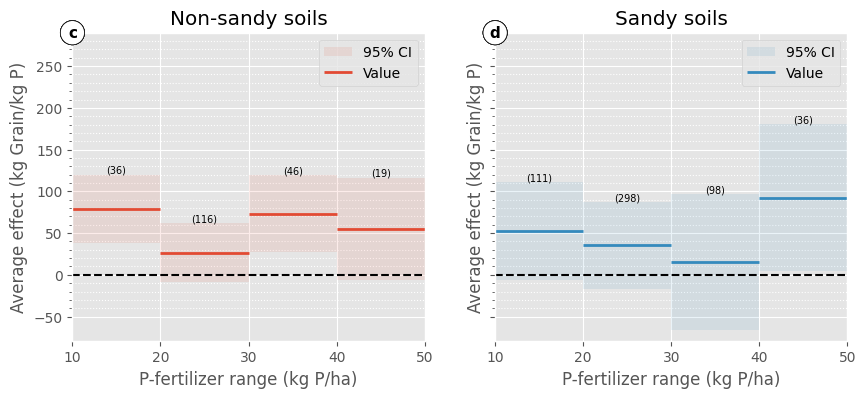

In [70]:
t_bins_coefs_df = pd.read_html(
    lineardml_amountcat_estimate.summary(feature_names=x_bin_sand_names).tables[0].as_html()
    , header=0, index_col=0
)[0]
t_bins_coefs_df['soil'] = t_bins_coefs_df.index.map(lambda x: x.split(':')[0])
t_bins_coefs_df['bin_low'] = t_bins_coefs_df.index.map(lambda x: x.split(':')[1].split('-')[0]).astype(int)

t_bins_coefs_df = pd.pivot_table(
    t_bins_coefs_df,
    values=['point_estimate', 'ci_lower', 'ci_upper'],
    columns=['soil'],
    index='bin_low'
)
t_bins_coefs_df.columns = pd.MultiIndex.from_tuples([
        ('Non-sandy', 'LowerCI'), ('Sandy', 'LowerCI'), ('Non-sandy', 'UpperCI'),
        ('Sandy', 'UpperCI'), ('Non-sandy', 'Mean'), ('Sandy', 'Mean')
    ])
t_bins_coefs_df = t_bins_coefs_df.sort_index()
t_bins_coefs_df

# Marginal response for quantile ranges
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True, sharex=False)
x = t_bins_coefs_df.index
x_ = x

for n, soil in enumerate(('Non-sandy', 'Sandy')):
    ax = axes[n]
    ax.axhline(0, color='k', linestyle='--')
    tmp_df = t_bins_coefs_df.loc[:, soil]
    T_ = T_absolute[X_sand[:, int('Non' in soil)].astype(bool)]
    for t, row in tmp_df.iterrows():
        ax.text(
            t + 5, row.UpperCI+2, f'({((T_ >= t) & (T_ < t+10)).sum()})', 
            ha='center', fontsize=7
        )
        ax.fill_between(
            x=[t, t+10], y1=row.LowerCI, y2=row.UpperCI,
            alpha=0.1, color=('#E24A33', '#348ABD')[n], linewidth=0, 
            label='95% CI' if t==T_bins[0] else None,
        )
        ax.hlines(
            y=row.Mean, xmin=t, xmax=t+10, linewidth=2,
            label='Value' if t == T_bins[0] else None,
            color=('#E24A33', '#348ABD')[n]
        )
        ax.set_xlabel('P-fertilizer range (kg P/ha)')
        ax.set_ylabel('Average effect (kg Grain/kg P)')
        ax.set_xticks(T_bins)
        # ax.set_xticklabels([f'{x_[i]:.0f}' for i, _ in enumerate(x_[:])], rotation=90)
        # ax.set_xticklabels([f'${{{i*100:.0f}}}^{{th}}$' for i in q], rotation=90)
        ax.set_xlim(T_bins[0], T_bins[-1])
        ax.set_title(f'{soil} soils')
        # ax.set_ylim(-15, 65)
        ax.set_yticks(np.arange(-50, 300, 10), minor=True)
        ax.grid(which='minor', linestyle=':')
        ax.legend(loc='upper right')
        ax.text(
            0, 1, ('c', 'd')[n], transform=ax.transAxes, va='center', ha='center', fontsize=11,
            fontweight='bold', bbox=dict(boxstyle='circle', fc='w', ec='k')
        )

fig.savefig('../figures/P-fertilizer-dose-category-effect.pdf', bbox_inches='tight', dpi=300)# pd.DataFrame(lift_inference, columns=['point_estimate', 'ci_lower', 'ci_upper'], index=x)
# t_bins_coefs

# Benchmark models

## Causal OLS

In [71]:
from statsmodels.api import OLS

In [72]:
# OLS model for homogeneous effect
ols_model_hom = OLS(
    endog=transformed_data_pstrimmed[outcome_name],
    exog=transformed_data_pstrimmed[features].join([
        (transformed_data_pstrimmed[treatment_name] * 
         (transformed_data_pstrimmed['soil_sandy'].astype(bool))).rename('P_sandy'),
        (transformed_data_pstrimmed[treatment_name] * 
         (~transformed_data_pstrimmed['soil_sandy'].astype(bool))).rename('P_nosandy')
    ]),
).fit().summary()
pd.read_html(
    ols_model_hom.tables[1].as_html()
    , header=0, index_col=0
)[0].loc[['P_sandy', 'P_nosandy']]

,coef,std err,t,P>|t|,[0.025,0.975]
P_sandy,50.6337,13.373,3.786,0.0,24.377,76.890
P_nosandy,49.8490,9.528,5.232,0.0,31.141,68.557


In [73]:
# OLS model for variable timing
endog = transformed_data_pstrimmed[outcome_name]
exog = transformed_data_pstrimmed[w_names]
exog = pd.concat([
    exog,
    pd.DataFrame(
        np.multiply(transformed_data_pstrimmed[[treatment_name]].to_numpy(), X),
        index=exog.index, columns=x_names_cate
    )
], axis=1)
ols_model_time = OLS(
    endog=endog,
    exog=exog,
).fit(sample_weight=sample_weights[transformed_data_pstrimmed.index]).summary()
pd.read_html(
    ols_model_time.tables[1].as_html()
    , header=0, index_col=0
)[0].loc[x_names_cate] 

,coef,std err,t,P>|t|,[0.025,0.975]
nosandy_other,5.0663,20.168,0.251,0.802,-34.531,44.663
nosandy_timing_100Basal,59.7103,11.707,5.100,0.000,36.724,82.696
nosandy_timing_100Emergence,40.9092,35.349,1.157,0.248,-28.496,110.314
nosandy_timing_100V56,38.1304,19.185,1.987,0.047,0.462,75.799
sandy_other,-54.6778,43.307,-1.263,0.207,-139.707,30.352
sandy_timing_100Basal,65.7929,16.253,4.048,0.000,33.882,97.704
sandy_timing_100Emergence,55.9193,29.938,1.868,0.062,-2.860,114.699
sandy_timing_100V56,-22.7206,41.562,-0.547,0.585,-104.324,58.882


## Predictive ML

In [74]:
from sklearn.base import clone
from sklearn.inspection import PartialDependenceDisplay, partial_dependence
# A RF with PDP to simulate the effect of fertilizer on yield
# This article was just released and it uses PDP: https://www.sciencedirect.com/science/article/pii/S1161030125004216
# X_rf_response = np.hstack([W, T.reshape(-1, 1)])

data_ml_pred = data.copy() # This uses all data, so the effect identification phase is skipped
data_ml_pred = data_ml_pred.drop(columns=['crop_name', 'crop_maize', 'outcome_prodkgha'])
data_ml_pred = data_ml_pred.loc[transformed_data_pstrimmed.index]
data_ml_pred[treatment_name] = transformed_data_pstrimmed[treatment_name]
data_ml_pred[outcome_name] = transformed_data_pstrimmed[outcome_name]
X_rf_response = data_ml_pred.drop(columns=[outcome_name])
Y_rf_response = data_ml_pred[outcome_name]
model_rf_response = clone(model_q)
y_cv_pred = cross_val_predict(
    model_rf_response,
    X_rf_response,
    Y_rf_response,
)
model_rf_response = model_rf_response.fit(X_rf_response, Y)
r2_score(Y_rf_response, y_cv_pred)

In [75]:
pd.Series(
    model_rf_response.feature_importances_,
    index=X_rf_response.columns
).sort_values(ascending=False).head(10)

fertP_total                 0.105929
fertN_total                 0.092957
fieldsize_value             0.060442
score_land                  0.056284
20to30perc_season_srad      0.027807
80to90perc_season_srad      0.025973
investing_capacity_index    0.023137
90to100perc_season_srad     0.022407
10to20perc_season_tmean     0.019629
0to10perc_season_tmean      0.018240
dtype: float64

In [76]:
X_rf_response_t0 = X_rf_response.copy()
X_rf_response_t0[treatment_name] = 0

model_rf_ite = (
    model_rf_response.predict(X_rf_response) - model_rf_response.predict(X_rf_response_t0)
)/X_rf_response[treatment_name]
model_rf_ite.describe()

count    786.000000
mean      17.864923
std       17.211618
min      -23.505458
25%        7.915549
50%       14.324613
75%       23.699864
max      152.765383
Name: fertP_total, dtype: float64

In [77]:
rf_response_pdp = partial_dependence(
    model_rf_response, X_rf_response, features=[treatment_name],
    kind='individual'
)

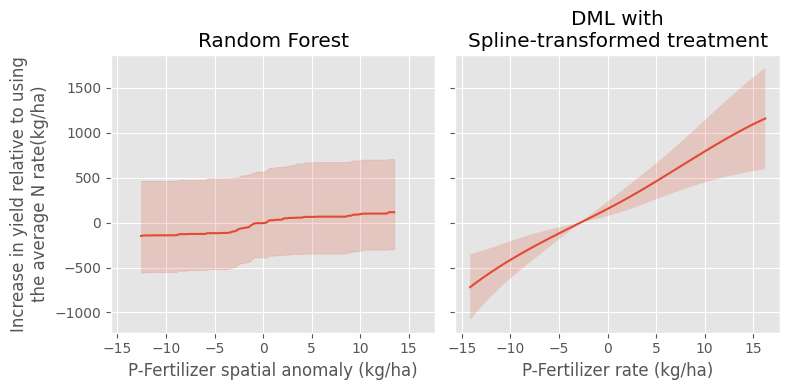

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharex=True, sharey=True)
ax = axes[0]
sns.lineplot(
    x=np.repeat(rf_response_pdp['grid_values'][0], len(Y)),
    y=rf_response_pdp['individual'][0].T.flatten(),
    errorbar='pi', ax=ax
)
ax.set_xlabel('P-Fertilizer spatial anomaly (kg/ha)')
ax.set_ylabel('Increase in yield relative to using\nthe average N rate(kg/ha)')
ax.set_title('Random Forest')

ax = axes[1]
plot_response_curve(lift_inference_rate['All'], ax, kwargs_ci=dict(alpha=.2), X=X_sand)
ax.set_title('DML with\nSpline-transformed treatment')
# ax.set_xlim(0, 100*T.max())

plt.tight_layout()

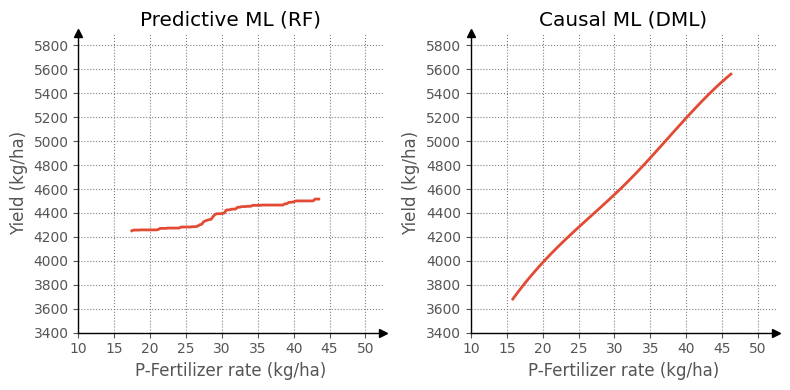

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharex=True, sharey=False)
ax = axes[0]
sns.lineplot(
    x=np.repeat(rf_response_pdp['grid_values'][0], len(Y)),
    y=rf_response_pdp['individual'][0].T.flatten(),
    errorbar=None, ax=ax, linewidth=2
)

ax.set_title('Predictive ML (RF)')

ax = axes[1]
plot_response_curve(
    lift_inference_rate['All'], ax, kwargs_ci=dict(alpha=.2), 
    ci=False, kwargs_line=dict(linewidth=2)
)
ax.set_title('Causal ML (DML)')

for ax in axes:
    xticks = np.arange(-20, 21, 5)
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticks+30)
    yticks = np.arange(-1000, 1500, 200)
    ax.set_yticks(yticks)
    ax.set_yticklabels(yticks+4400)
    ax.set_xlabel('P-Fertilizer rate (kg/ha)')
    ax.set_ylabel('Yield (kg/ha)')
    ax.set_xlim(xticks[0], xticks[-1]+2.5)
    ax.set_ylim(yticks[0], yticks[-1]+100)

    ax.grid(linestyle=':', color='grey')
    ax.set_facecolor('w')
    ax.spines['left'].set_color('k')
    ax.spines['bottom'].set_color('k')
    ax.spines['right'].set_color(None)
    ax.spines['top'].set_color(None)
    ax.plot(1, 0, ">k", transform=ax.transAxes, clip_on=False)
    ax.plot(0, 1, "^k", transform=ax.transAxes, clip_on=False)

# ax.text(5.2, 0.1, 'X', fontsize=12, fontweight='bold')

# ax.set_xticklabels([''])
plt.tight_layout()

# Sensitivity analysis

In [80]:
lineardml_hom_estimate.sensitivity_summary()

<class 'econml.utilities.Summary'>
"""
Sensitivity Analysis Summary for c_y=0.05, c_t=0.05, rho=1.0
================================================
CI Lower Theta Lower Theta  Theta Upper CI Upper
------------------------------------------------
  23.895      38.489 48.716      58.943   73.599
   Robustness Values for null_hypothesis=0    
==============================================
Robustness Value (Theta) Robustness Value (CI)
----------------------------------------------
                   0.216                 0.156
----------------------------------------------
"""

In [81]:
lineardml_time_estimate.sensitivity_summary()

<class 'econml.utilities.Summary'>
"""
Sensitivity Analysis Summary for c_y=0.05, c_t=0.05, rho=1.0
================================================
CI Lower Theta Lower Theta  Theta Upper CI Upper
------------------------------------------------
  25.733      39.933 49.941      59.948   74.195
   Robustness Values for null_hypothesis=0    
==============================================
Robustness Value (Theta) Robustness Value (CI)
----------------------------------------------
                   0.225                 0.166
----------------------------------------------
"""

In [82]:
lineardml_amountcat_estimate.sensitivity_summary()

<class 'econml.utilities.Summary'>
"""
Sensitivity Analysis Summary for c_y=0.05, c_t=0.05, rho=1.0
================================================
CI Lower Theta Lower Theta  Theta Upper CI Upper
------------------------------------------------
  25.849      42.852 54.812      66.771   83.918
   Robustness Values for null_hypothesis=0    
==============================================
Robustness Value (Theta) Robustness Value (CI)
----------------------------------------------
                   0.209                 0.149
----------------------------------------------
"""

## Placebo test

In [83]:
from tqdm import tqdm

In [84]:
t25, t75

In [85]:
# Run placebo for the Timing and Amount heterogeneous estimators
placebo_ate_estimates_dict = {
    'No Het.': [],
    'Amount rate': [],
    'Amount Cat.': [],
    'Appl. Strat.': []
}
# placebo_ate_estimates_dict['Amount rate'] = []
placebo_rate_response = []
placebo_t_grid = np.quantile(T, np.linspace(0.025, 0.975, 100))

N_PLACEBO_RUNS = 0
if N_PLACEBO_RUNS < 1:
    with open('P-response-placebo', 'rb') as f:
        placebo_ate_estimates_dict, placebo_rate_response = pickle.load(f)

for _ in tqdm(range(N_PLACEBO_RUNS)):
    T_placebo = np.random.choice(T_absolute, size=len(T_absolute), replace=True)
    # Heterogeneous by amount
    lineardml_amount_placebo = LinearDML(
        model_y=model_q, 
        model_t=MultiOutputRegressor(model_treatment), 
        treatment_featurizer=treatment_featurizer,
        discrete_treatment=False,
        cv=5,
        random_state=RANDOM_SEED,
        fit_cate_intercept=False,
    )
    lineardml_amount_placebo = lineardml_amount_placebo.fit(
        Y=Y, T=T_placebo.reshape(-1, 1), W=W, X=X_sand,
        inference='statsmodels', cache_values=True,
    )
    placebo_ate_estimates_dict['Amount rate'].append(lineardml_amount_placebo.ate(X_sand, T0=t25, T1=t75)/(t75-t25))
    placebo_rate_response.append(
        np.array([
            lineardml_amount_placebo.ate(X_sand, T0=0, T1=i) 
            for i in np.quantile(T_placebo, np.linspace(0.025, 0.975, 100))
        ])
    )

0it [00:00, ?it/s]


In [86]:
placebo_ate_estimates_dict['Appl. Strat.'] = []
for _ in tqdm(range(N_PLACEBO_RUNS)):
    T_placebo = np.random.choice(T, size=len(T), replace=True)
    # Heterogeneous by time
    lineardml_time_placebo = LinearDML(
        model_y=model_q, 
        model_t=model_treatment, 
        discrete_treatment=False,
        cv=5,
        random_state=RANDOM_SEED,
        fit_cate_intercept=False,
    )
    lineardml_time_placebo = lineardml_time_placebo.fit(
        Y=Y, T=T_placebo, W=W, X=X,
        inference='statsmodels', cache_values=True,
        sample_weight=sample_weights[transformed_data_pstrimmed.index]
    )
    placebo_ate_estimates_dict['Appl. Strat.'].append(lineardml_time_placebo.ate(X))

0it [00:00, ?it/s]


In [87]:
for _ in tqdm(range(N_PLACEBO_RUNS)):
    T_placebo = np.random.choice(T, size=len(T), replace=True)
    # Rate heterogeneous with binned rates
    lineardml_amountcat_placebo = LinearDML(
        model_y=model_q, 
        model_t=model_treatment, 
        discrete_treatment=False,
        cv=5,
        random_state=RANDOM_SEED,
        fit_cate_intercept=False, 
    )
    lineardml_amountcat_placebo = lineardml_amountcat_placebo.fit(
        Y=Y, T=T_placebo, W=W, X=X_bins_sand,
        inference='statsmodels', cache_values=True,
    )
    placebo_ate_estimates_dict['Amount Cat.'].append(lineardml_amountcat_placebo.ate(X))

0it [00:00, ?it/s]


In [88]:
for _ in tqdm(range(N_PLACEBO_RUNS)):
    T_placebo = np.random.choice(T, size=len(T), replace=True)
    # Heterogeneous by Soil 
    lineardml_time_placebo = LinearDML(
        model_y=model_q, 
        model_t=model_treatment, 
        discrete_treatment=False,
        cv=5,
        random_state=RANDOM_SEED,
        fit_cate_intercept=False,
    )
    lineardml_time_placebo = lineardml_time_placebo.fit(
        Y=Y, T=T_placebo, W=W, X=X_sand,
        inference='statsmodels', cache_values=True,
    )
    placebo_ate_estimates_dict['No Het.'].append(lineardml_time_placebo.ate(X_sand))

0it [00:00, ?it/s]


In [89]:
with open('P-response-placebo', 'wb') as f:
    pickle.dump((placebo_ate_estimates_dict, placebo_rate_response), f)

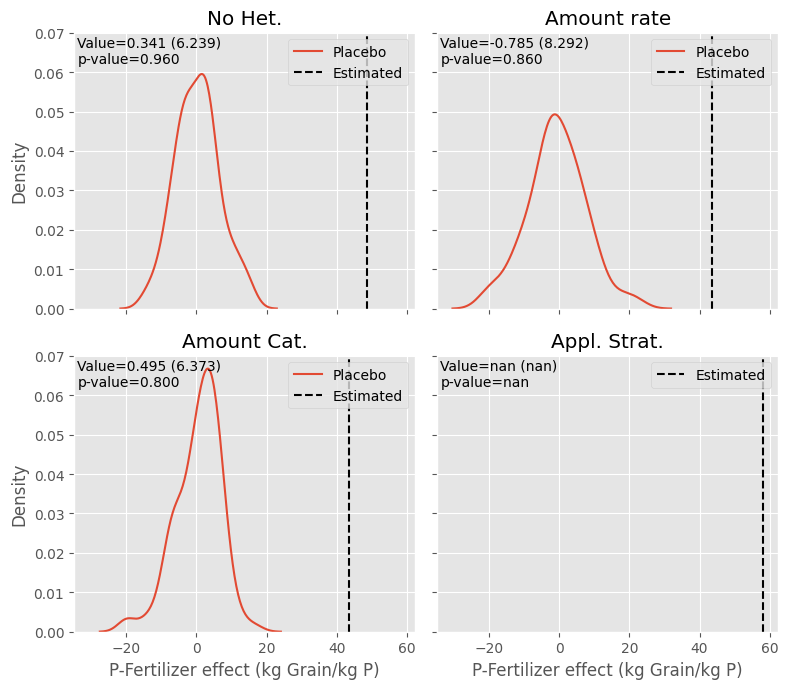

In [90]:
fig, axes = plt.subplots(2, 2, figsize=(8, 7), sharex=True, sharey=True)
axes = axes.flatten()
for n, (est_name, placebo_estimates) in enumerate(placebo_ate_estimates_dict.items()):
    ax = axes[n]
    sns.kdeplot(np.array(placebo_estimates).flatten(), label='Placebo', ax=ax)
    ax.set_xlabel('P-Fertilizer effect (kg Grain/kg P)')
    ax.set_title(est_name)
    ate_ = ate_df.loc[(est_name, 'ATE')]['Mean']
    ax.axvline(ate_, label='Estimated', color='k', linestyle='--')
    p_value = 2*min((np.array(placebo_estimates) >= 0).mean(), (np.array(placebo_estimates) < 0).mean())
    ax.text(
        0.01, 0.99, 
        f'Value={np.mean(placebo_estimates):.3f} ({np.std(placebo_estimates):.3f})', 
        transform=ax.transAxes, va='top'
    )
    ax.text(0.01, 0.93, f"p-value={p_value:.3f}", transform=ax.transAxes, va='top')
    ax.legend(loc='upper right')
    # ax.set_xlim(-30, 25)
plt.tight_layout()
fig.savefig('../figures/P-fertilizer-ate-placebo-tests.pdf', bbox_inches='tight', dpi=300)

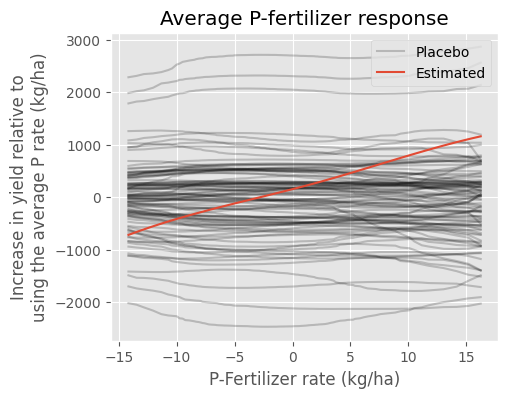

In [91]:
fig, ax =plt.subplots(1, 1, figsize=(5, 4))

for est in placebo_rate_response:
    plot_response_curve(
        est, ax, ci=False, kwargs_line=dict(color='k', alpha=.2),
        X=X_sand, t_grid=placebo_t_grid
    )
plot_response_curve(
    est, ax, ci=False, kwargs_line=dict(color='k', alpha=.2, label='Placebo'),
    X=X_sand
)
plot_response_curve(
    lift_inference_rate['All'], ax, ci=False, kwargs_line=dict(label='Estimated'),
    X=X_sand
)


ax.set_title('Average P-fertilizer response')
# ax.set_xlim(0, 100*T.max())
ax.legend()
fig.savefig('../figures/P-fertilizer-dose-response-curve-placebo.pdf', bbox_inches='tight', dpi=300)

In [148]:
tmp_df = (appl_clusters_df.groupby('Cluster name').agg(('mean' , 'std'))*100).astype(int)
tmp_df = tmp_df.filter(like='fertP').drop(columns='fertP_total')
order_col = [
    'fertP_basal', 'fertP_emergence', 'fertP_56leaves', 'fertP_kneehigh', 
    'fertP_810leaves', 'fertP_tasselingsilking'
]
index_map = {k.replace('timing_', ''): v for k, v in timing_pretty_names.items()}
index_map['0Noise'] = 'Other'
tmp_df.index = tmp_df.index.map(index_map)
tmp_df = tmp_df.loc[cluster_order, order_col]
for idx, row in tmp_df.iterrows():
    print(idx.replace('%', '\%')+'&{0} ({1}) & {2} ({3}) & {4} ({5}) & {6} ({7}) & {8} ({9}) &{10} ({11})\\\\'.format(*row.values))

Other&27 (28) & 6 (16) & 11 (21) & 13 (31) & 38 (39) &2 (10)\\
100\% V5-6&0 (0) & 0 (0) & 100 (0) & 0 (0) & 0 (0) &0 (0)\\
100\% Emergence&0 (0) & 100 (0) & 0 (0) & 0 (0) & 0 (0) &0 (0)\\
100\% Basal&99 (0) & 0 (0) & 0 (0) & 0 (0) & 0 (0) &0 (0)\\


# In-depth Analysis

## Test difference between soil groups

In [92]:
# Create a DataFrame to store the difference in effects test results
diff_test_results = pd.DataFrame(
    columns=['Mean Difference (Non-sandy - Sandy)', 'SE Difference', 'Z-statistic', 'P-value']
)

def z_test_diff_means(mean1, mean2, se1, se2):
    diff_mean = mean1 - mean2
    se_diff = np.sqrt(se1**2 + se2**2)
    # Calculate the Z-statistic
    if se_diff != 0:
        z_statistic = diff_mean / se_diff
        p_value = 2 * stats.norm.sf(np.abs(z_statistic))
    else:
        z_statistic = np.nan
        p_value = np.nan # Or 1.0 if diff_mean is also 0, but nan is safer for general case
    return z_statistic, p_value

from itertools import combinations
def pairwise_ztest(df, grouping_col, compare_col, mean_col, se_col):
    out_df = []
    for g in df[grouping_col].unique():
        tmp_df = df.loc[df[grouping_col] == g].set_index(compare_col)
        # print(tmp_df)
        for g1, g2 in combinations(tmp_df.index, 2):
            if g1 == g2:
                continue
            mean1 = tmp_df.loc[g1, mean_col]
            mean2 = tmp_df.loc[g2, mean_col]
            se1 = tmp_df.loc[g1, se_col]
            se2 = tmp_df.loc[g2, se_col]
            z_statistic, p_value = z_test_diff_means(mean1, mean2, se1, se2)
            out_df.append((
                g, g1, g2, mean1 - mean2, z_statistic, p_value
            ))
    out_df = pd.DataFrame(
        out_df, 
        columns=[grouping_col, 'Group1', 'Group2', 'Diff', 'Zstat', 'pvalue']
    )
    return pd.DataFrame(out_df).set_index([grouping_col, 'Group1', 'Group2']).sort_index()
tmp_df = ate_df.reset_index()
tmp_df = tmp_df.loc[tmp_df['Soil'] != 'ATE']
pairwise_ztest(tmp_df, 'Estimate', 'Soil', 'Mean', "SE")

,,,Diff,Zstat,pvalue
Estimate,Group1,Group2,,,
Amount Cat.,Non-sandy,Sandy,8.651440,0.420519,0.674106
Amount rate,Non-sandy,Sandy,-37.982678,-1.481527,0.138466
Appl. Strat.,Non-sandy,Sandy,-0.033716,-0.001711,0.998634
No Het.,Non-sandy,Sandy,0.265395,0.015683,0.987487


In [93]:
tmp_df = timing_coefs.reset_index()
pairwise_ztest(tmp_df, 'level_1', 'level_0', 'point_estimate', "stderr")

,,,Diff,Zstat,pvalue
level_1,Group1,Group2,,,
100% Basal,Non-sandy,Sandy,6.278,0.247613,0.804434
100% Emergence,Non-sandy,Sandy,-17.310,-0.340431,0.733532
100% V5-6,Non-sandy,Sandy,0.556,0.014847,0.988154
Other,Non-sandy,Sandy,30.481,0.747619,0.454690


In [94]:
timing_pairwise = pairwise_ztest(tmp_df, 'level_0', 'level_1', 'point_estimate', "stderr")
timing_pairwise.loc[timing_pairwise.pvalue<0.05]

Diff     Zstat    pvalue
level_0   Group1     Group2                                     
Non-sandy 100% Basal 100% V5-6        45.272  2.083239  0.037229
          Other      100% Basal      -77.046 -3.706208  0.000210
Sandy     Other      100% Basal     -101.249 -2.339538  0.019308
                     100% Emergence  -99.796 -2.016084  0.043791

In [95]:
timing_coefs

point_estimate  stderr  zstat  pvalue  ci_lower  \
Non-sandy Other                   -3.630  16.737 -0.217   0.828   -36.434   
          100% Basal              73.416  12.330  5.954   0.000    49.250   
          100% Emergence          48.375  38.953  1.242   0.214   -27.971   
          100% V5-6               28.144  17.895  1.573   0.116    -6.930   
Sandy     Other                  -34.111  37.177 -0.918   0.359  -106.976   
          100% Basal              67.138  22.154  3.030   0.002    23.717   
          100% Emergence          65.685  32.682  2.010   0.044     1.630   
          100% V5-6               27.588  32.897  0.839   0.402   -36.888   

                          ci_upper  
Non-sandy Other             29.174  
          100% Basal        97.582  
          100% Emergence   124.721  
          100% V5-6         63.218  
Sandy     Other             38.754  
          100% Basal       110.560  
          100% Emergence   129.740  
          100% V5-6         92.065

In [146]:
((1-0.19)*.22)/0.19